In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
dataset = pd.read_csv('https://raw.githubusercontent.com/UmerBhikan/Predicting-sales-of-Tractors-Time-Series-/master/Tractor-Sales.csv')

In [3]:
dataset

,Month-Year,Number of Tractor Sold
0,Jan-03,141
1,Feb-03,157
2,Mar-03,185
3,Apr-03,199
4,May-03,203
...,...,...
139,Aug-14,848
140,Sep-14,640
141,Oct-14,581
142,Nov-14,519


In [4]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 2 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   Month-Year              144 non-null    object
 1   Number of Tractor Sold  144 non-null    int64 
dtypes: int64(1), object(1)
memory usage: 2.4+ KB


In [5]:
len(dataset)
# 2003 to 2014

144

In [6]:
dates = pd.date_range(start= '2003-01-01', periods=len(dataset), freq='MS')

In [7]:
dates.month

Index([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10,
       ...
        3,  4,  5,  6,  7,  8,  9, 10, 11, 12],
      dtype='int32', length=144)

In [8]:
import calendar
dataset['Month']= dates.month
dataset['Month'] = dataset['Month'].apply(lambda x : calendar.month_abbr[x])

In [9]:
dataset['Year'] = dates.year

In [10]:
dataset

,Month-Year,Number of Tractor Sold,Month,Year
0,Jan-03,141,Jan,2003
1,Feb-03,157,Feb,2003
2,Mar-03,185,Mar,2003
3,Apr-03,199,Apr,2003
4,May-03,203,May,2003
...,...,...,...,...
139,Aug-14,848,Aug,2014
140,Sep-14,640,Sep,2014
141,Oct-14,581,Oct,2014
142,Nov-14,519,Nov,2014


In [11]:
import calendar

In [12]:
calendar.month_abbr[1]

'Jan'

In [13]:
dataset.head(2)

,Month-Year,Number of Tractor Sold,Month,Year
0,Jan-03,141,Jan,2003
1,Feb-03,157,Feb,2003


In [14]:
dataset.rename(columns= {'Number of Tractor Sold' : 'Tractor-Sales'}, inplace = True)

In [15]:
dataset

,Month-Year,Tractor-Sales,Month,Year
0,Jan-03,141,Jan,2003
1,Feb-03,157,Feb,2003
2,Mar-03,185,Mar,2003
3,Apr-03,199,Apr,2003
4,May-03,203,May,2003
...,...,...,...,...
139,Aug-14,848,Aug,2014
140,Sep-14,640,Sep,2014
141,Oct-14,581,Oct,2014
142,Nov-14,519,Nov,2014


In [16]:
dates = pd.date_range(start= '2003-01-01', periods=len(dataset), freq='MS')
dates

DatetimeIndex(['2003-01-01', '2003-02-01', '2003-03-01', '2003-04-01',
               '2003-05-01', '2003-06-01', '2003-07-01', '2003-08-01',
               '2003-09-01', '2003-10-01',
               ...
               '2014-03-01', '2014-04-01', '2014-05-01', '2014-06-01',
               '2014-07-01', '2014-08-01', '2014-09-01', '2014-10-01',
               '2014-11-01', '2014-12-01'],
              dtype='datetime64[ns]', length=144, freq='MS')

In [17]:
dataset.set_index(dates, inplace=True)

In [18]:
dataset = dataset[['Tractor-Sales', 'Month', 'Year']]

In [19]:
dataset.head(2)

,Tractor-Sales,Month,Year
2003-01-01,141,Jan,2003
2003-02-01,157,Feb,2003


In [20]:
ts_sales = dataset['Tractor-Sales']

In [21]:
ts_sales

2003-01-01    141
2003-02-01    157
2003-03-01    185
2003-04-01    199
2003-05-01    203
             ... 
2014-08-01    848
2014-09-01    640
2014-10-01    581
2014-11-01    519
2014-12-01    605
Freq: MS, Name: Tractor-Sales, Length: 144, dtype: int64

<AxesSubplot:>

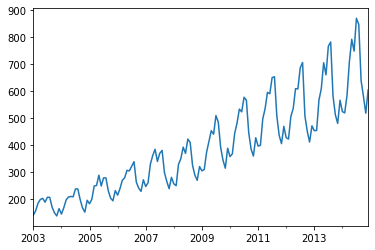

In [22]:
ts_sales.plot()
# Trend is observed here

In [23]:
# decompose
# cycle season , trends
from statsmodels.tsa.seasonal import seasonal_decompose

In [24]:
# Inside seasonal_decompose we have two types of models additative and multiplicative
decompose = seasonal_decompose(ts_sales)

In [25]:
#decompose.trend

In [26]:
#decompose.resid

In [27]:
#decompose.seasonal

In [28]:
#plt.plot(decompose.resid)

In [29]:

#plt.plot(decompose.seasonal)

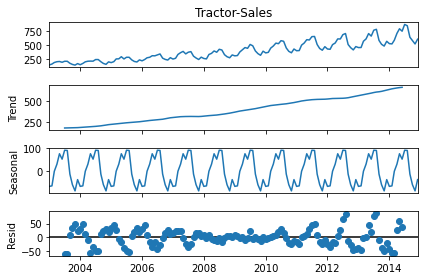

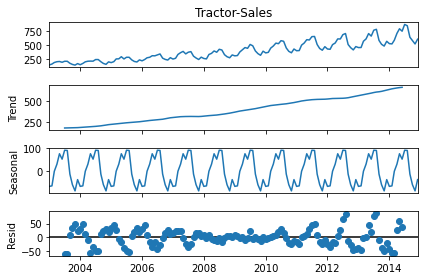

In [30]:
decompose.plot()

In [31]:
#plt.plot(decompose.trend)

In [32]:
#decompose.plot();

In [33]:
# Simple moving average
# rolling stats
# we can use any window
# we are using past 4 datapts to calculate mean
ts_sales.rolling(window=4).mean()

2003-01-01       NaN
2003-02-01       NaN
2003-03-01       NaN
2003-04-01    170.50
2003-05-01    186.00
               ...  
2014-08-01    815.25
2014-09-01    777.00
2014-10-01    735.00
2014-11-01    647.00
2014-12-01    586.25
Freq: MS, Name: Tractor-Sales, Length: 144, dtype: float64

In [34]:
# window 4 previ value to take mean 

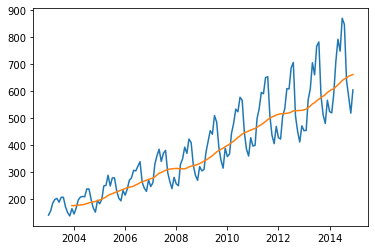

In [35]:
plt.plot(ts_sales)
plt.plot(ts_sales.rolling(window=12).mean())

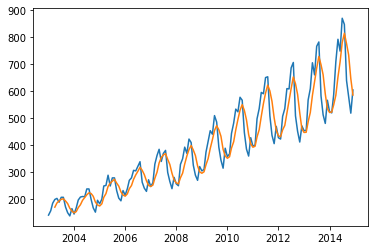

In [36]:
plt.plot(ts_sales)
plt.plot(ts_sales.rolling(window=4).mean())


In [37]:
# to analysis data with resp to time 
# ts_sales is my original data
# by window we are doing smoothing
# if we take window size as 4
# 1. take a mean of ts_sales from first 4 records = 141+157+185+199/4
# mean = 170.5
# now it will roll out this entire data wrt to whole window
# after calculating mean = 4 th value replace with mean and first 3 will replace with NAN
# and again I will start calculate the mean of 4 from 2 nd record before 
# after this it will keep on rolling for 4 windows
# mv using for model building and analysis for data


In [38]:
#ts_sales.rolling(window = 12).mean().head(15)

In [39]:
#ts_sales.rolling(window = 4).mean().head(12)

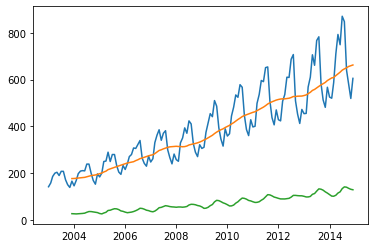

In [40]:
plt.plot(ts_sales)
plt.plot(ts_sales.rolling(window=12).mean())
plt.plot(ts_sales.rolling(window=12).std())


In [41]:
# Analysis
#
ts_sales.rolling(window=12).std()

2003-01-01           NaN
2003-02-01           NaN
2003-03-01           NaN
2003-04-01           NaN
2003-05-01           NaN
                 ...    
2014-08-01    140.409439
2014-09-01    139.057433
2014-10-01    134.254846
2014-11-01    130.136874
2014-12-01    128.137237
Freq: MS, Name: Tractor-Sales, Length: 144, dtype: float64

In [42]:
# this timeseries is not stationary

In [43]:
# auto regression - regression within a variable
# first 5 values is my independent variable - 6 th value we are predicting
# predicting from previous time stamp
# auto corelation - within time stamp

In [44]:
#2003 -2014 - 144 months

In [45]:
# Some More Visulization

In [46]:
dataset.head(1)

,Tractor-Sales,Month,Year
2003-01-01,141,Jan,2003


In [47]:
 update_data = pd.pivot(dataset, values='Tractor-Sales', index = 'Month', columns = 'Year')

<AxesSubplot:xlabel='Month'>

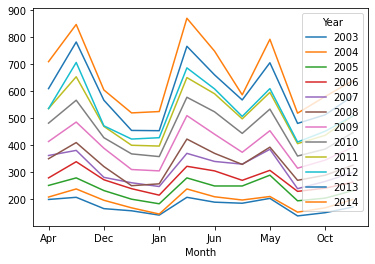

In [48]:
update_data.plot()

In [49]:
# 
#pd.pivot(dataset, values='Tractor-Sales', index = 'Year', columns = 'Month')

In [50]:
# Ploting year and month wise data 
 #pd.pivot(dataset, values='Tractor-Sales', index = 'Year', columns = 'Month').plot()

In [51]:
#Tractor sales Year wise
#pd.pivot(df, values='Tractor-Sales', index = 'Year', columns = 'Month').plot()

In [52]:
# Box plot year wise  with box plot
#pd.pivot(df, values='Tractor-Sales', index = 'Year', columns = 'Month').boxplot()

In [53]:
#import seaborn as sns
#sns.distplot(ts_sales)

In [56]:
from statsmodels.tsa.stattools import adfuller

In [57]:
# to checck the staticstics , data stationary or not 
dftest = adfuller(ts_sales)

In [58]:
dftest

(1.1088250591467306,
 0.9952912415248419,
 14,
 129,
 {'1%': -3.482087964046026,
  '5%': -2.8842185101614626,
  '10%': -2.578864381347275},
 1082.5357724796872)

In [59]:
len(dftest)
dftest[0:4]

(1.1088250591467306, 0.9952912415248419, 14, 129)

In [60]:
dfoutput=pd.Series(dftest[0:4],index=['statical value','p-value','#lags','number of obervation'])

In [61]:
dfoutput

statical value            1.108825
p-value                   0.995291
#lags                    14.000000
number of obervation    129.000000
dtype: float64

In [62]:
def test_stationary(time_series):
    roll_mean = time_series.rolling(12).mean()
    roll_std  = time_series.rolling(12).std()
    
    plt.figure(figsize=(18,10))
    plt.grid('both')
    plt.plot(time_series)
    plt.plot(roll_mean)
    plt.plot(roll_std)
    
    print("------------------------------")
    print('Results of Augmented dicky fuller Test: ')
    dftest = adfuller(time_series, autolag='AIC')
    dfoutput = pd.Series(dftest[0:4], index=['Test Statistic', 'P-value', 'Lags Used', 'No of Observations'])
    for key ,value in dftest[4].items():
        dfoutput['Confidense Interval (%s)'%key] = value
    print(dfoutput)

------------------------------
Results of Augmented dicky fuller Test: 
Test Statistic                 1.108825
P-value                        0.995291
Lags Used                     14.000000
No of Observations           129.000000
Confidense Interval (1%)      -3.482088
Confidense Interval (5%)      -2.884219
Confidense Interval (10%)     -2.578864
dtype: float64


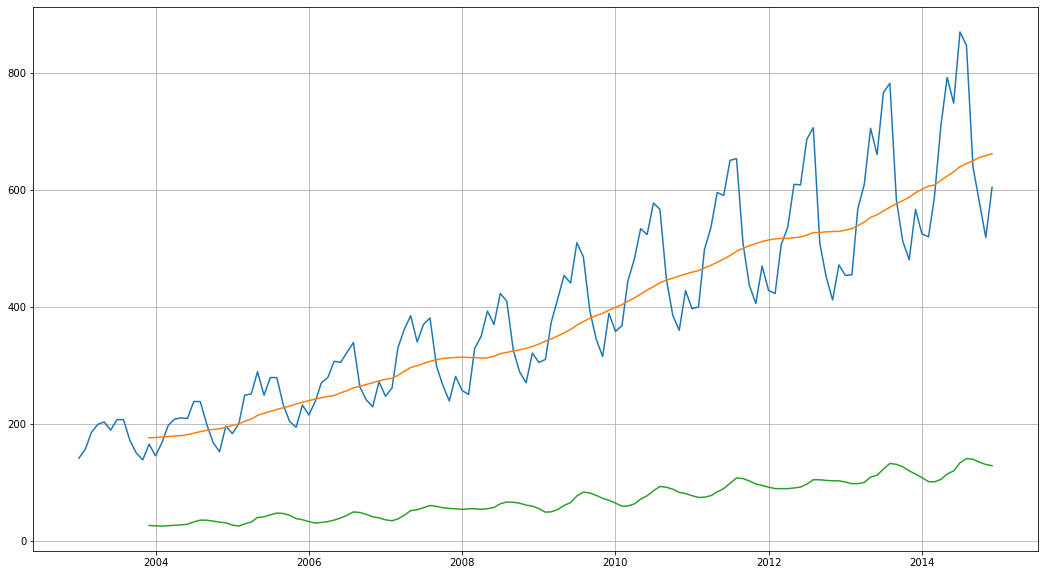

In [63]:
test_stationary(ts_sales)

In [64]:
# Mean is rolling not 0 
# data is not stationarary
# 

In [65]:
# Differencing to make data stationary

------------------------------
Results of Augmented dicky fuller Test: 
Test Statistic                -2.543481
P-value                        0.105250
Lags Used                     14.000000
No of Observations           128.000000
Confidense Interval (1%)      -3.482501
Confidense Interval (5%)      -2.884398
Confidense Interval (10%)     -2.578960
dtype: float64


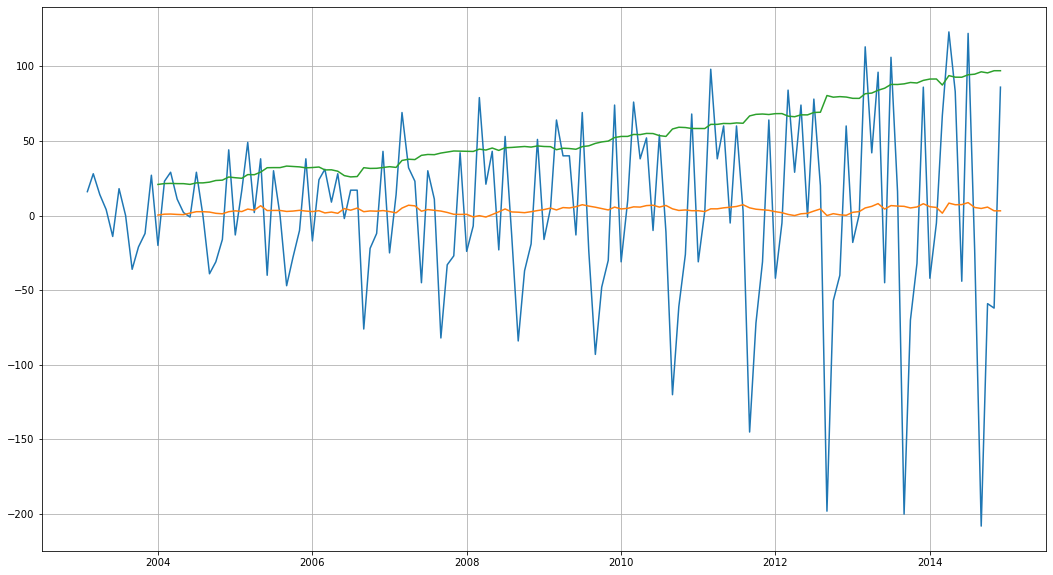

In [66]:
one_diff_data = ts_sales.diff(periods=1)
one_diff_data.dropna(inplace=True)
test_stationary(one_diff_data)



In [67]:
#one_diff_data.isna().sum()

In [68]:
import numpy as np
# convert data into log transformation
#log_diff_data = np.log(ts_sales)

log_diff_data = np.log(ts_sales).diff(periods=1).dropna()

------------------------------
Results of Augmented dicky fuller Test: 
Test Statistic                -3.200722
P-value                        0.019943
Lags Used                     11.000000
No of Observations           130.000000
Confidense Interval (1%)      -3.481682
Confidense Interval (5%)      -2.884042
Confidense Interval (10%)     -2.578770
dtype: float64


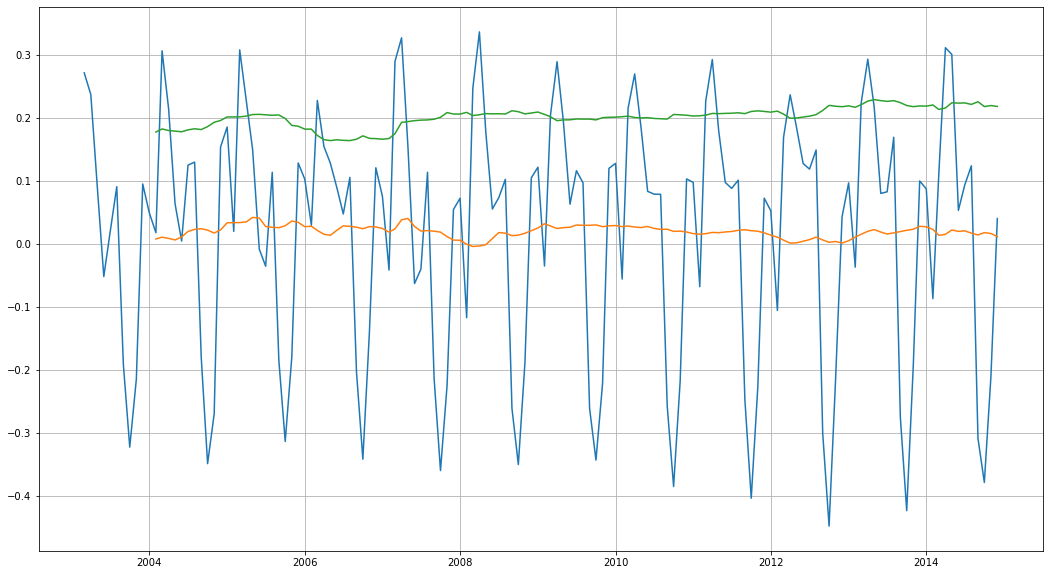

In [69]:
log_diff_data2 = np.log(ts_sales).diff(periods=2).dropna()
test_stationary(log_diff_data2)

In [70]:
#ARIMA
#SARIMA
# PACF ACF
#AIC BIC
# MSE
#PREDICTION
# OUTOFBOX FORECASTING

In [71]:
import statsmodels.api as sm
import statsmodels.tsa.api as smt
import statsmodels.formula.api as smf

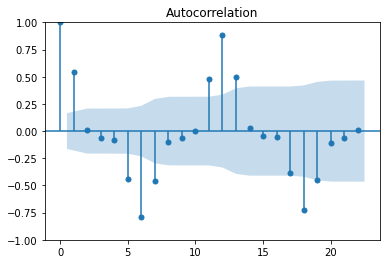

In [72]:
smt.graphics.plot_acf(log_diff_data2);

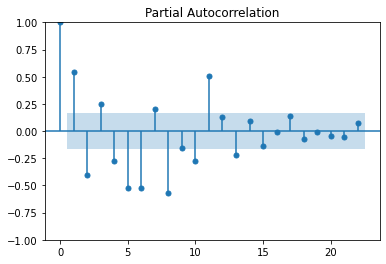

In [73]:
smt.graphics.plot_pacf(log_diff_data2);

In [74]:
import os
import warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
#import statsmodels.api as sm
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.arima_model import ARIMA
import warnings
warnings.filterwarnings('ignore')
from sklearn.metrics import mean_squared_error, mean_absolute_error
import math
import yfinance as yf
from pmdarima.arima import auto_arima
from statsmodels.graphics.tsaplots import plot_acf,plot_pacf

ModuleNotFoundError: No module named 'pmdarima'

In [ ]:
from statsmodels.tsa.arima_model import ARIMA
#model = ARIMA(log_diff_data2,order=(1,1,1))

In [75]:
#m_fit= model.fit()
#m_fit.forecast()

In [76]:
#mse
#np.sqrt(mean_squared_error(y,prediction))


In [148]:
def arima_model(x,y,arima_order):
    history=[i for i in x]
    prediction=list()
    for i in range(len(y)):
        model=ARIMA(history,order=arima_order)
        model_fit=model.fit()
        yhat=model_fit.forecast()[0]
        prediction.append(yhat)
        history.append(y[i])
    mse=np.sqrt(mean_squared_error(y,prediction))
    return mse
    
    

In [157]:
p_value = range(0,3)
d_value = range(0,3)
q_value = range(0,3)

In [158]:
def evaluate_arima_model(dataset, test, p_value, d_value, q_value):
    dataset = dataset.astype('float32')
    best_score, best_cfg =float('inf'),None
    for i in p_value:
        for j in d_value:
            for k in q_value:
                order=(i,j,k)
                rmse = arima_model(dataset,test,order)
                if rmse < best_score:
                    best_score, best_cfg=rmse, order
                    print(rmse,order)
                else:
                    continue
    print(f"best rmse and best cfg {best_score}, {best_cfg} : ")

In [162]:
def evalute_arima_model(dataset,test,p_value,d_value,q_value):
    dataset=dataset.astype('float32')
    best_score,best_cfg=float('inf'),None
    for i in p_value:
        for j in d_value:
            for k in q_value:
                order=(i,j,k)
               
                try:
                    rmse=arima_model(dataset,test,order)
                    if rmse < best_score:
                        best_score,best_cfg=rmse,order
                    print("ARIMA%s, RMSE=%.3f" %(order,rmse))
                except Exception as e:
                    print(e)
                    print("error")
                    continue
            
    print(f"best_score and best_cfg {best_score}{best_cfg}")

In [163]:
log_diff_data2.dtype

dtype('float64')

In [164]:
evaluate_arima_model(train_data, test_data, p_value,d_value, q_value)

0.21869254618710854 (0, 0, 0)
0.14466602066520126 (0, 0, 1)
0.14283450992826208 (0, 0, 2)
0.13406568261492377 (1, 0, 2)
0.12352207311371623 (2, 0, 2)
best rmse and best cfg 0.12352207311371623, (2, 0, 2) : 


In [80]:
#len(ts_sales) = 144
# 12 months
# last two months data as test data
# 24 
# 144-24 = 120

train_data = log_diff_data2[:120]
test_data  = log_diff_data2[120:]





In [81]:
#evaluate_arima_model(train_data, test_data, p_value, d_value, q_value)

In [82]:
import statsmodels

In [83]:
#!pip install stasmodels==0.14.0

In [90]:
import statsmodels.api as sm
data = [ i for i in train_data]
model = sm.tsa.arima.ARIMA(data, order=(1,1,2))
m_fit = model.fit()
m_fit.forecast()[0]

0.00012461877884849953

In [106]:
from statsmodels.tsa.arima.model import ARIMA
data = [ i for i in train_data]
model = ARIMA(data,order=(2,0,2))


In [107]:
m_fit = model.fit()

In [108]:
pred = m_fit.forecast()[0]

In [109]:
pred

0.08890490413609484

In [110]:
# It is predicting 121

In [111]:
oringal = log_diff_data2[120]

In [112]:
m_fit.bic

-144.6081060682804

In [113]:
m_fit.aic

-161.33305652497268

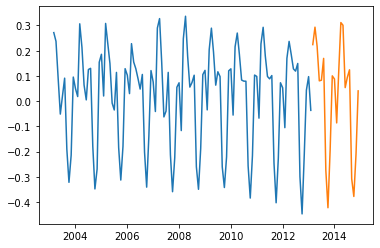

In [114]:
plt.plot(train_data)
plt.plot(test_data)